
# 1️⃣ Import des Librairies
Cette section permet d'importer toutes les bibliothèques nécessaires pour l'analyse, le nettoyage et la préparation des données.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

# 2️⃣ Collecte des Données

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving german.data to german.data


In [ ]:
df = pd.read_csv("german.data", sep=" ", header=None)

print("Shape :", df.shape)
df.head()

Shape : (1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


# 3️⃣ Définition des Colonnes

In [ ]:
columns = [
    "Status", "Duration", "Credit_history", "Purpose", "Credit_amount",
    "Savings", "Employment", "Installment_rate", "Personal_status",
    "Other_debtors", "Residence_since", "Property", "Age",
    "Other_installment_plans", "Housing", "Existing_credits",
    "Job", "Num_people_liable", "Telephone", "Foreign_worker", "Risk"
]

df.columns = columns
df.head()

,Status,Duration,Credit_history,Purpose,Credit_amount,Savings,Employment,Installment_rate,Personal_status,Other_debtors,...,Property,Age,Other_installment_plans,Housing,Existing_credits,Job,Num_people_liable,Telephone,Foreign_worker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


# 4️⃣ Transformation de la Variable Cible
1 = Bon client
2 = Client à risque

Transformation en :
0 = Bon client
1 = Client à risque

In [ ]:
df["Risk"] = df["Risk"].astype(int)
df["Risk"] = df["Risk"].map({1: 0, 2: 1})

df["Risk"].value_counts()

,count
Risk,
0,700
1,300


# 5️⃣ Analyse Statistique Descriptive

In [ ]:
df.describe()

,Duration,Credit_amount,Installment_rate,Residence_since,Age,Existing_credits,Num_people_liable,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


# 6️⃣ Vérification des Valeurs Manquantes

In [ ]:
df.isnull().sum()

,0
Status,0
Duration,0
Credit_history,0
Purpose,0
Credit_amount,0
Savings,0
Employment,0
Installment_rate,0
Personal_status,0
Other_debtors,0


# 7️⃣ Vérification des Valeurs Incohérentes

In [ ]:
print("Age min/max :", df["Age"].min(), df["Age"].max())
print("Credit_amount min :", df["Credit_amount"].min())
print("Duration min :", df["Duration"].min())

Age min/max : 19 75
Credit_amount min : 250
Duration min : 4


# 8️⃣ Analyse du Déséquilibre des Classes

In [ ]:
df["Risk"].value_counts(normalize=True)

,proportion
Risk,
0,0.7
1,0.3


# 9️⃣ Détection des Outliers (Méthode IQR)

In [ ]:
numeric_cols = df.select_dtypes(include=["int64"]).columns

def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

for col in numeric_cols:
    detect_outliers(col)

Duration: 70 outliers
Credit_amount: 72 outliers
Installment_rate: 0 outliers
Residence_since: 0 outliers
Age: 23 outliers
Existing_credits: 6 outliers
Num_people_liable: 155 outliers
Risk: 0 outliers


# 🔟 Visualisation des Outliers

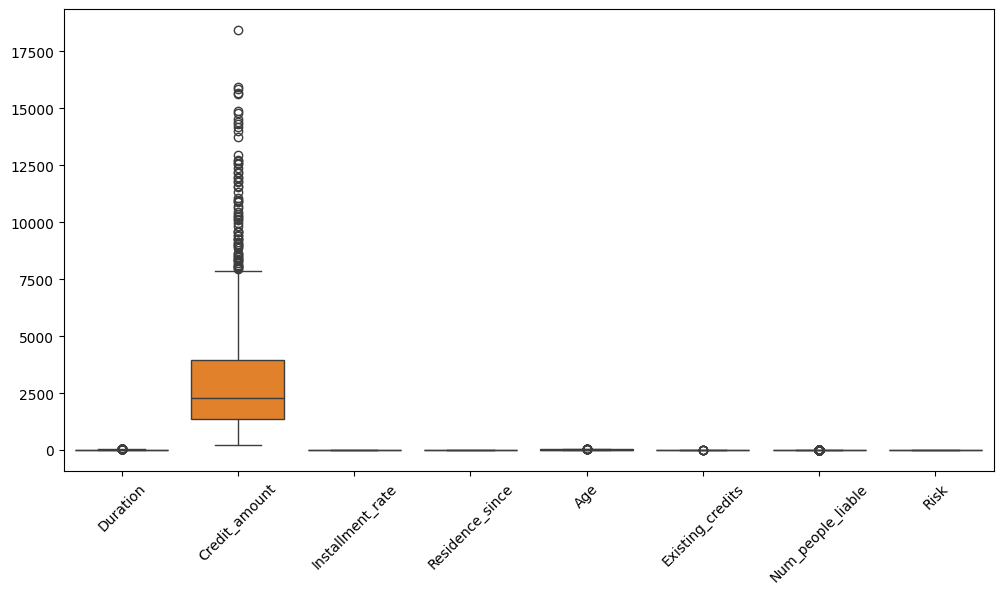

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

# 1️⃣1️⃣ Séparation des Features et de la Target

In [ ]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

# 1️⃣2️⃣ Identification des Variables Numériques et Catégorielles

In [ ]:
numeric_features = X.select_dtypes(include=["int64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numériques :", numeric_features)
print("Catégorielles :", categorical_features)

Numériques : Index(['Duration', 'Credit_amount', 'Installment_rate', 'Residence_since',
       'Age', 'Existing_credits', 'Num_people_liable'],
      dtype='object')
Catégorielles : Index(['Status', 'Credit_history', 'Purpose', 'Savings', 'Employment',
       'Personal_status', 'Other_debtors', 'Property',
       'Other_installment_plans', 'Housing', 'Job', 'Telephone',
       'Foreign_worker'],
      dtype='object')


# 1️⃣3️⃣ Construction du Pipeline de Prétraitement

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# 1️⃣4️⃣ Séparation Train/Test (Stratifiée)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 20)
Test shape: (200, 20)


# 1️⃣5️⃣ Application du Pipeline

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train shape:", X_train_processed.shape)

Processed Train shape: (800, 61)


# 1️⃣6️⃣ Sauvegarde du Pipeline (Reproductibilité)

In [ ]:
# Sauvegarde des données prêtées pour le Modèle
pd.DataFrame(X_train_processed).to_csv('X_train_clean.csv', index=False)
pd.DataFrame(X_test_processed).to_csv('X_test_clean.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


In [ ]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']